# **Juan Andres Duarte**
# **200547253**

# **Project: Smart Health & Lifestyle Prediction System (Weeks 1–11)**

# **Activity Part 1 — Load & Explore Dataset**

In [1]:
# Upload project_health_dataset.csv
from google.colab import files
uploaded = files.upload()

Saving project_health_dataset.csv to project_health_dataset (1).csv


In [2]:

# TODO 1: Load dataset (project_health_dataset.csv) using pandas

import pandas as pd

df = pd.read_csv('project_health_dataset.csv')

# TODO 2: Preview first 5 rows

print("First 5 rows:")
print(df.head())


# TODO 3: Check dataset info, missing values, duplicates

print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:")
print(df.duplicated().sum())

# TODO 4: Describe statistical summary of numerical features

print("\nSummary numerical features:")
print(df.describe())




First 5 rows:
   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore      100 non-null    int64  
 5   StressLeve

# **Activity Part 2 — Data Cleaning & Feature Engineering**

In [3]:
# TODO 5: Fill missing numerical values with mean

df = df.fillna(df.mean(numeric_only=True))

# TODO 6: Fill missing categorical values with mode

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

# TODO 7: Remove duplicates

df = df.drop_duplicates()

# TODO 8: Create new features:
#         WellnessIndex = HoursExercise * HoursSleep
#         BMI Category: Underweight, Normal, Overweight, Obese

df["WellnessIndex"] = df["HoursExercise"] * df["HoursSleep"]
df["BMI_Category"] = df["BMI"].apply(lambda x: "Underweight" if x < 18.5 else "Normal" if x < 25 else "Overweight" if x < 30 else "Obese")


# Reset the columns in the df so add the encoded columns can be run multiple times
df = df[[ "Age", "Gender", "HoursExercise", "HoursSleep", "DietScore", "StressLevel", "BMI", "HealthScore", "WellnessIndex", "BMI_Category"]]


# TODO 9: Encode categorical variables (Gender, BMI Category)

df_encoded_gender = pd.get_dummies(df["Gender"])
df_encoded_BMI_Category = pd.get_dummies(df["BMI_Category"])

# Add encoded columns to df

df = pd.concat([df, df_encoded_gender, df_encoded_BMI_Category], axis=1)
df.head()


,Age,Gender,HoursExercise,HoursSleep,DietScore,StressLevel,BMI,HealthScore,WellnessIndex,BMI_Category,Female,Male,Normal,Obese,Overweight
0,56,Male,13,5,7,3,18.9,0,65,Normal,False,True,True,False,False
1,46,Female,4,4,1,5,34.3,0,16,Obese,True,False,False,True,False
2,32,Female,0,7,3,6,32.4,1,0,Obese,True,False,False,True,False
3,25,Female,2,7,2,9,24.0,1,14,Normal,True,False,True,False,False
4,38,Male,9,4,9,5,34.3,0,36,Obese,False,True,False,True,False


# **Activity Part 3 — Data Visualization**

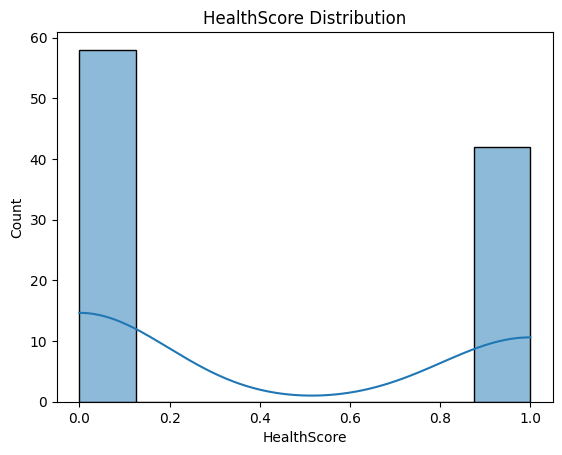

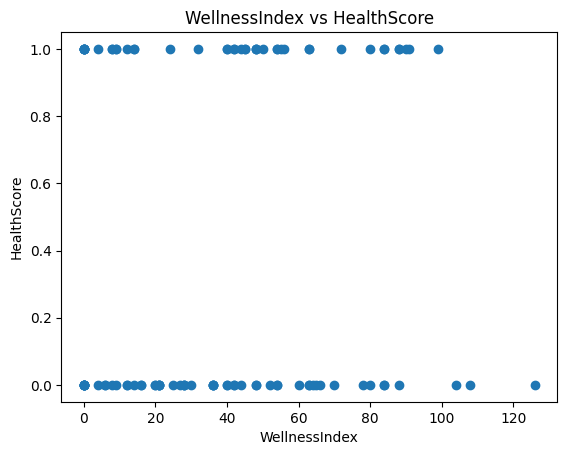

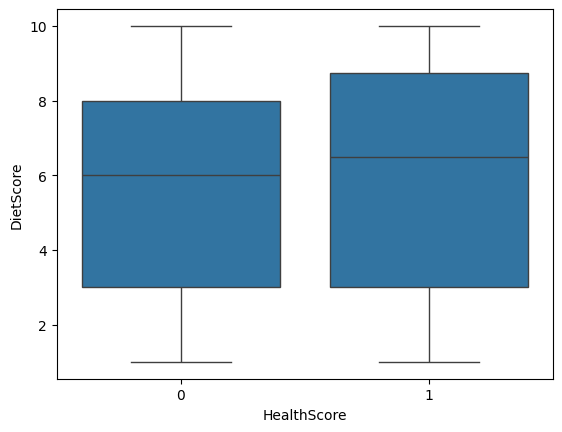

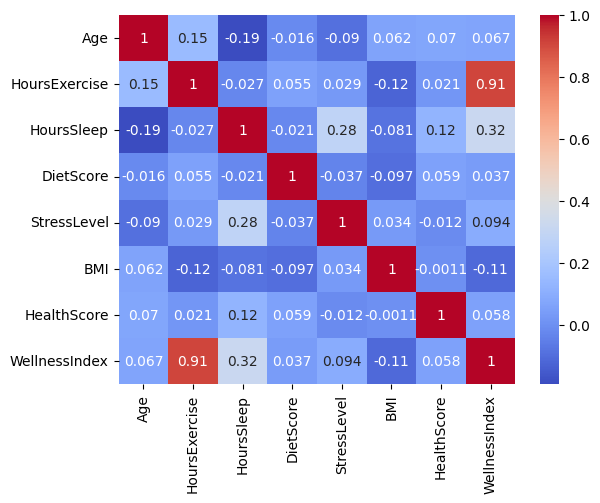

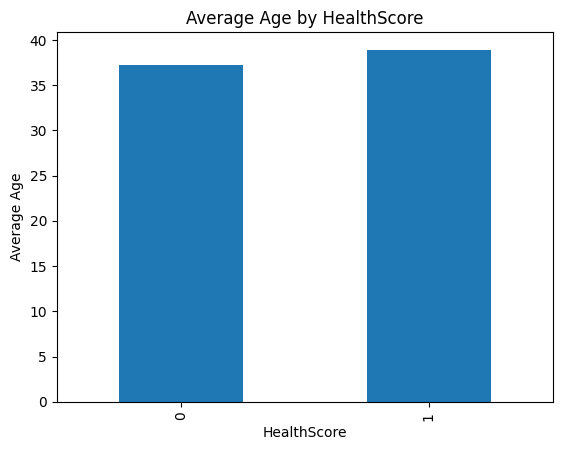

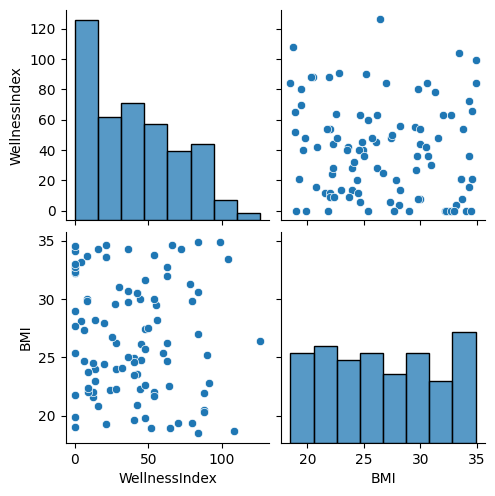

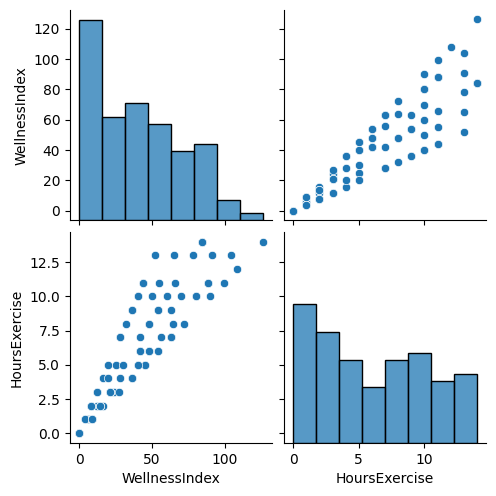

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO 10: Histogram of HealthScore

sns.histplot(df["HealthScore"], kde=True)
plt.title("HealthScore Distribution")
plt.show()

# TODO 11: Scatter plot: WellnessIndex vs HealthScore

plt.scatter(df["WellnessIndex"], df["HealthScore"])
plt.title("WellnessIndex vs HealthScore")
plt.xlabel("WellnessIndex")
plt.ylabel("HealthScore")
plt.show()

# TODO 12: Boxplot: DietScore vs HealthScore

sns.boxplot(x=df["HealthScore"], y=df["DietScore"])
plt.show()


# TODO 13: Heatmap of feature correlations

corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# TODO 14: Any other visualizations to explore patterns

# Bar Chart — Average Age by HealthScore
avg_BMI = df.groupby("HealthScore")["Age"].mean()
avg_BMI.plot(kind="bar")
plt.title("Average Age by HealthScore")
plt.xlabel("HealthScore")
plt.ylabel("Average Age")
plt.show()

# BPairplot WellnessIndex vs BMI Analysis
sns.pairplot(df, vars=["WellnessIndex", "BMI",])
plt.show()

# BPairplot WellnessIndex vs HoursExercise Analysis
sns.pairplot(df, vars=["WellnessIndex", "HoursExercise",])
plt.show()

# **Activity Part 4 — Supervised Machine Learning**

In [5]:
# TODO 15: Split dataset into X (features) and y (HealthScore)
# TODO 16: Split data into train/test sets (80/20)
# TODO 17: Train KNN model, evaluate accuracy, confusion matrix, classification report
# TODO 18: Train Random Forest, Logistic Regression, and SVM models
# TODO 19: Compare models using accuracy and F1-score

# **Activity Part 5 — Neural Network Programming**

In [6]:
# TODO 20: Standardize features using StandardScaler
# TODO 21: Build a simple feedforward neural network (1-2 hidden layers)
# TODO 22: Train network on training data, validate on test data
# TODO 23: Plot loss and accuracy curves
# TODO 24: Evaluate predictions using confusion matrix

# **Activity Part 6 — K-Fold Cross-Validation**


In [7]:
# TODO 25: Implement K-Fold (k=5 or 10) on one ML model (e.g., Random Forest)
# TODO 26: Record mean accuracy and variance across folds

# **Activity Part 7 — Dimensionality Reduction**

In [8]:
# TODO 27: Apply PCA to reduce features to 2 components
# TODO 28: Visualize first 2 PCA components with color by HealthScore
# TODO 29: Apply LDA (if supervised) to separate classes
# TODO 30: Compare PCA vs LDA scatter plots

# **Activity Part 8 — Insights & Recommendations**

In [9]:
# TODO 31: Summarize observations from visualizations
# TODO 32: Compare model performances, explain best model
# TODO 33: Suggest lifestyle improvements based on predictions